In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay


In [3]:
# 1 Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
print(df.head())


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [4]:
# MPG = miles per gallon (our target)
# The higher the MPG → the more fuel-efficient the car.

# 2 Select useful columns
numeric_features = ["displacement", "horsepower", "weight", "acceleration", "model_year"]
categorical_features = ["origin"]
df = df[numeric_features + categorical_features + ["mpg"]]

In [5]:
# Drop rows without target (mpg)
df = df.dropna(subset=["mpg"])

In [6]:
# 3 Split data into features (X) and target (y)
X = df[numeric_features + categorical_features]
y = df["mpg"]

In [7]:
# Train-test split → 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (318, 6) | Test shape: (80, 6)


In [8]:
# 4 Preprocessing
# GBR requires numbers only and no missing values.
# - Numeric: fill missing with median.
# - Categorical: fill missing with most frequent, then one-hot encode.
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


In [9]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])


In [10]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [11]:
# 5️⃣ Define the Gradient Boosting Regressor model
# Gradient Boosting = builds trees one by one, each correcting previous errors.
gbr = GradientBoostingRegressor(
    n_estimators=300,    # how many trees (iterations)
    learning_rate=0.05,  # how strongly each new tree corrects mistakes
    max_depth=3,         # complexity of each tree
    subsample=0.9,       # use 90% of data per tree → adds randomness, reduces overfitting
    random_state=42
)


In [12]:
# Combine preprocessing + model into one pipeline
model = Pipeline([
    ("preprocess", preprocessor),
    ("gbr", gbr)
])


In [14]:
# 6 Train (fit) the model
model.fit(X_train, y_train)

# 7 Predict on test data
y_pred = model.predict(X_test)



In [16]:
# 8 Evaluate model performance
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [17]:
print(f"\nRMSE: {rmse:.2f} mpg")
print(f"R² score: {r2:.3f}")



RMSE: 5.48 mpg
R² score: 0.898


In [18]:

# 9 Feature importance
trained_pre = model.named_steps["preprocess"]
trained_gbr = model.named_steps["gbr"]

# Get encoded feature names
ohe = trained_pre.named_transformers_["cat"].named_steps["ohe"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
final_feature_names = numeric_features + cat_names

importances = pd.Series(trained_gbr.feature_importances_, index=final_feature_names)
importances = importances.sort_values(ascending=False)
print("\nTop feature importances:")
print(importances.head(10))


Top feature importances:
weight           0.355487
displacement     0.354304
model_year       0.164000
horsepower       0.096169
acceleration     0.024256
origin_usa       0.003755
origin_japan     0.001050
origin_europe    0.000978
dtype: float64


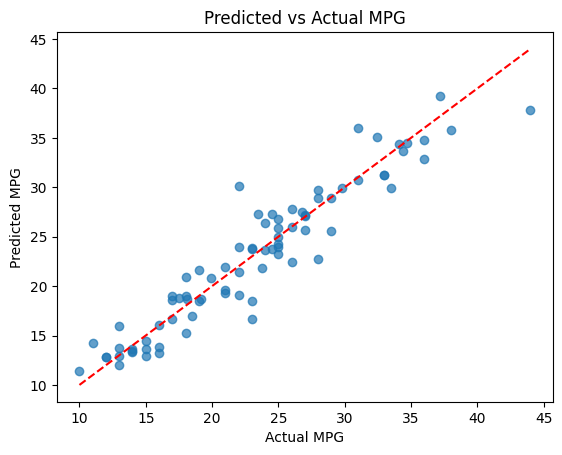

In [19]:
# Plot predicted vs actual MPG
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted vs Actual MPG")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.show()

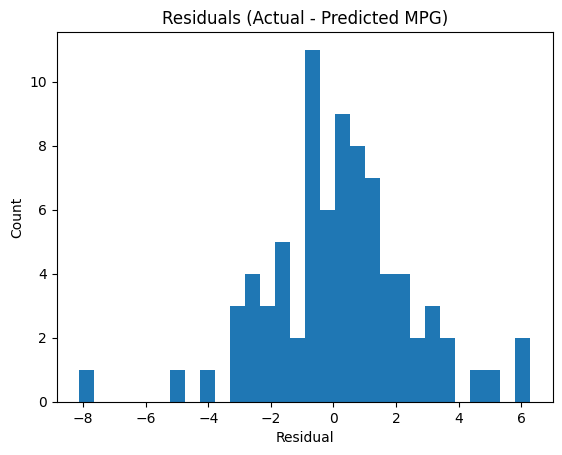

In [20]:
# 10 Residuals (how far off predictions were)
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residuals (Actual - Predicted MPG)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

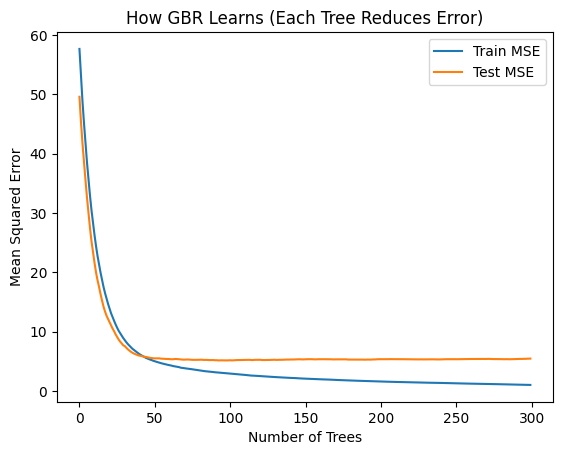

In [21]:
# 11 Boosting Dynamics — how error changes as trees are added
X_train_trans = trained_pre.transform(X_train)
X_test_trans = trained_pre.transform(X_test)

train_mse, test_mse = [], []
for y_pred_train in trained_gbr.staged_predict(X_train_trans):
    train_mse.append(mean_squared_error(y_train, y_pred_train))
for y_pred_test in trained_gbr.staged_predict(X_test_trans):
    test_mse.append(mean_squared_error(y_test, y_pred_test))

plt.figure()
plt.plot(train_mse, label="Train MSE")
plt.plot(test_mse, label="Test MSE")
plt.xlabel("Number of Trees")
plt.ylabel("Mean Squared Error")
plt.title("How GBR Learns (Each Tree Reduces Error)")
plt.legend()
plt.show()


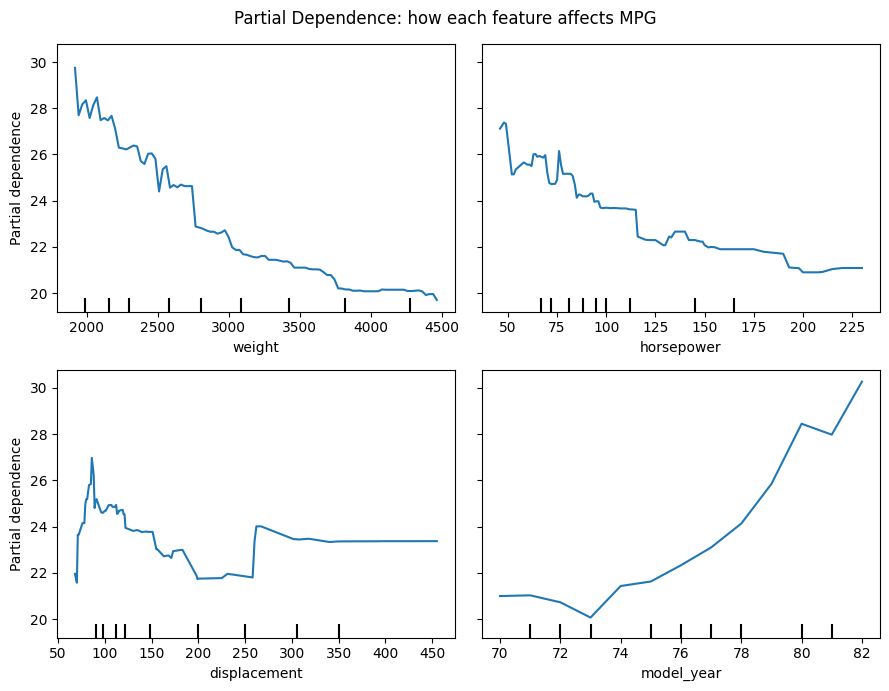

In [22]:
# 12 Partial Dependence Plots (Why predictions change)
features_to_explain = ["weight", "horsepower", "displacement", "model_year"]
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
PartialDependenceDisplay.from_estimator(model, X, features=features_to_explain, ax=axs)
plt.suptitle("Partial Dependence: how each feature affects MPG")
plt.tight_layout()
plt.show()